### 1:- What is a Support Vector Machine (SVM)?

A **Support Vector Machine (SVM)** is a powerful and versatile machine learning algorithm primarily used for classification, regression, and outlier detection. Its core idea is to find an optimal hyperplane that best separates data points of different classes in a high-dimensional space.

**Key Concepts:**

*   **Hyperplane:** In a classification task, the SVM algorithm attempts to find a decision boundary, called a hyperplane, that separates the different classes of data points.
*   **Support Vectors:** These are the data points closest to the hyperplane. They are the most difficult to classify and play a critical role in defining the hyperplane and the margin. Only these points influence the position and orientation of the hyperplane.
*   **Margin:** The margin is the distance between the hyperplane and the nearest data point from either class (the support vectors). SVMs aim to maximize this margin, as a larger margin generally leads to better generalization and a more robust classifier.

**How it works (for classification):**

1.  **Find the Optimal Hyperplane:** The SVM algorithm searches for the hyperplane that maximizes the margin between the two classes.
2.  **Handle Non-linear Data (Kernel Trick):** For data that is not linearly separable, SVMs use a technique called the **kernel trick**. This involves mapping the original data into a higher-dimensional feature space where it may become linearly separable. Common kernels include the Linear, Polynomial, and Radial Basis Function (RBF) kernels.
3.  **Soft Margin Classification:** In real-world scenarios, data often overlaps, and it might not be possible to find a perfectly separating hyperplane without misclassifying some points. Soft margin SVMs introduce a **slack variable** and a **regularization parameter (C)** to allow some misclassifications or violations of the margin, balancing between maximizing the margin and minimizing classification errors.

**Advantages:**

*   Effective in high-dimensional spaces.
*   Still effective in cases where the number of dimensions is greater than the number of samples.
*   Uses a subset of training points in the decision function (support vectors), making it memory efficient.
*   Versatile: different Kernel functions can be specified for the decision function.

**Disadvantages:**

*   Can be computationally intensive for large datasets.
*   Choice of kernel and regularization parameter (C) can significantly impact performance and requires careful tuning.
*   Less effective on noisy datasets with overlapping classes where the classes are not clearly separable.

### 2:- What is the difference between Hard Margin and Soft Margin SVM?

The primary distinction between Hard Margin SVM and Soft Margin SVM lies in how they handle **misclassifications** and **non-linearly separable data**.

#### 1. Hard Margin SVM

*   **Definition:** Hard Margin SVM aims to find a hyperplane that perfectly separates the different classes, with no training data points allowed to cross the margin or be misclassified.
*   **Conditions for Use:**
    *   The data must be **linearly separable** (meaning a straight line or hyperplane can perfectly divide the classes).
    *   The data must be **noise-free** or have very few outliers.
*   **Advantages:**
    *   Conceptually simpler.
    *   If a perfect separation exists, it finds the widest possible margin, which often leads to good generalization.
*   **Disadvantages:**
    *   Very sensitive to outliers; a single outlier can drastically change the hyperplane or make the problem unsolvable.
    *   Cannot be used if the data is not perfectly linearly separable (which is common in real-world datasets).
    *   Often leads to overfitting if the data is only *almost* linearly separable but has some noise.

#### 2. Soft Margin SVM

*   **Definition:** Soft Margin SVM allows for some misclassifications or violations of the margin to achieve a more robust and generalized model. It introduces **slack variables** (ξ) to measure the degree of misclassification and a **regularization parameter (C)** to control the trade-off between maximizing the margin and minimizing the classification error.
*   **Conditions for Use:**
    *   When the data is **not perfectly linearly separable**.
    *   When the data contains **noise or outliers**.
*   **Advantages:**
    *   More practical and widely applicable to real-world datasets.
    *   Less sensitive to outliers compared to Hard Margin SVM.
    *   Provides a way to balance model complexity and generalization error (bias-variance trade-off) using the `C` parameter.
*   **Disadvantages:**
    *   Requires tuning of the `C` parameter.
    *   The hyperplane might not perfectly separate all training data points.

#### Key Differences Summarized:

| Feature           | Hard Margin SVM                          | Soft Margin SVM                                   |
| :---------------- | :--------------------------------------- | :------------------------------------------------ |
| **Separation**    | Perfect (no misclassifications)          | Allows some misclassifications and margin violations |
| **Data Type**     | Strictly linearly separable & noise-free | Linearly or non-linearly separable, can handle noise |
| **Robustness**    | Not robust to outliers                   | Robust to outliers                                |
| **Parameters**    | None (besides kernel choice)             | `C` (regularization parameter), kernel choice     |
| **Real-world Use**| Rare                                     | Very common and practical                         |

### 3:- What is the mathematical intuition behind SVM?

The mathematical intuition behind Support Vector Machines (SVM) revolves around finding an **optimal separating hyperplane** in a high-dimensional space. The "optimal" part means finding the hyperplane that maximizes the **margin** between the different classes.

Let's consider a binary classification problem with two classes, labeled as +1 and -1.

#### 1. The Decision Boundary (Hyperplane)

In a 2D space, a hyperplane is a line. In a 3D space, it's a plane. In an N-dimensional space, it's an (N-1)-dimensional hyperplane. This hyperplane is defined by the equation:

$$\mathbf{w} \cdot \mathbf{x} + b = 0$$

Where:
*   $\mathbf{w}$ is the **weight vector** (normal to the hyperplane).
*   $\mathbf{x}$ is a data point.
*   $b$ is the **bias** or intercept term.

For any given data point $\mathbf{x}_i$ and its corresponding class label $y_i \in \{-1, +1\}$:
*   If $y_i = +1$, we want $\mathbf{w} \cdot \mathbf{x}_i + b > 0$.
*   If $y_i = -1$, we want $\mathbf{w} \cdot \mathbf{x}_i + b < 0$.

To ensure a clear separation, we can introduce a functional margin, demanding that for correctly classified points:

*   $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1$

#### 2. The Margin and Support Vectors

The points that satisfy $y_i (\mathbf{w} \cdot \mathbf{x}_i + b) = 1$ are called the **support vectors**. These are the points closest to the hyperplane and define the boundaries of the margin. The hyperplane itself lies exactly in the middle of these support vectors.

The distance from the origin to the hyperplane is given by $|b| / ||\mathbf{w}||$. The distance between the two hyperplanes that pass through the support vectors ($H_1: \mathbf{w} \cdot \mathbf{x} + b = 1$ and $H_2: \mathbf{w} \cdot \mathbf{x} + b = -1$) is the **margin**, which is equal to $2 / ||\mathbf{w}||$.

#### 3. The Optimization Problem

The goal of SVM is to find the $\mathbf{w}$ and $b$ that maximize this margin. Maximizing $2 / ||\mathbf{w}||$ is equivalent to minimizing $||\mathbf{w}||$, or more conveniently, minimizing $1/2 ||\mathbf{w}||^2$ (to make the optimization problem convex and differentiable).

So, the optimization problem for a **Hard Margin SVM** can be formulated as:

Minimize: $$\frac{1}{2} ||\mathbf{w}||^2$$
Subject to: $$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \text{for all } i$$

#### 4. Soft Margin and Slack Variables

For **Soft Margin SVM**, where some misclassifications are allowed, we introduce **slack variables** $\xi_i \geq 0$. These variables measure how much a data point violates the margin or is misclassified.

*   If $\xi_i = 0$, the point is correctly classified and outside the margin.
*   If $0 < \xi_i < 1$, the point is correctly classified but within the margin.
*   If $\xi_i \geq 1$, the point is misclassified.

The new optimization problem becomes:

Minimize: $$\frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{n} \xi_i$$
Subject to: $$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i \quad \text{for all } i$$
And: $$\xi_i \geq 0 \quad \text{for all } i$$

Here, $C$ is a regularization parameter that controls the trade-off between maximizing the margin (minimizing $||\mathbf{w}||^2$) and minimizing the training error (minimizing $\sum \xi_i$). A small $C$ allows for a wider margin but more misclassifications, while a large $C$ aims for fewer misclassifications but a narrower margin.

#### 5. The Kernel Trick

For non-linearly separable data, SVM uses the **Kernel Trick**. Instead of explicitly transforming the data into a higher-dimensional space (which can be computationally expensive), the kernel function $\phi(\mathbf{x})$ is used to compute the dot product of the transformed vectors in that higher-dimensional space without ever actually performing the transformation:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

This allows SVM to learn non-linear decision boundaries efficiently. The optimization problem then involves $K(\mathbf{x}_i, \mathbf{x}_j)$ instead of $\mathbf{x}_i \cdot \mathbf{x}_j$.

### 4:-What is the role of Lagrange Multipliers in SVM?

Lagrange Multipliers play a crucial role in the mathematical formulation and solution of Support Vector Machines (SVMs), particularly in transforming the original optimization problem into a more tractable dual form. This dual form is essential for several reasons, including the ability to apply the **kernel trick**.

#### The Primal Problem (briefly revisited):
As seen in the mathematical intuition, the optimization problem for a Hard Margin SVM is:

Minimize: $$\frac{1}{2} ||\mathbf{w}||^2$$
Subject to: $$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \text{for all } i$$

This is a constrained optimization problem. To solve such problems, we often use the method of Lagrange Multipliers.

#### Constructing the Lagrangian:
We introduce a set of Lagrange multipliers, $\alpha_i \geq 0$, one for each constraint. The Lagrangian function is then formed by combining the objective function and the constraints:

$$\mathcal{L}(\mathbf{w}, b, \alpha) = \frac{1}{2} ||\mathbf{w}||^2 - \sum_{i=1}^{n} \alpha_i [y_i (\mathbf{w} \cdot \mathbf{x}_i + b) - 1]$$

Where:
*   $\mathbf{w}$ is the weight vector.
*   $b$ is the bias.
*   $\alpha_i$ are the Lagrange multipliers, with $\alpha_i \geq 0$.

#### The Dual Problem:
The SVM optimization is solved by finding the saddle point of this Lagrangian. This involves:
1.  Taking partial derivatives of $\mathcal{L}$ with respect to $\mathbf{w}$ and $b$, and setting them to zero. This allows us to express $\mathbf{w}$ and $b$ in terms of $\alpha_i$ and the training data.
2.  Substituting these expressions back into the Lagrangian. This eliminates $\mathbf{w}$ and $b$, resulting in the **Lagrangian Dual Problem**, which is solely in terms of $\alpha_i$ and dot products of the input features $\mathbf{x}_i$.

The dual problem for Hard Margin SVM becomes:

Maximize: $$\sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (\mathbf{x}_i \cdot \mathbf{x}_j)$$
Subject to: $$\sum_{i=1}^{n} \alpha_i y_i = 0$$
And: $$\alpha_i \geq 0 \quad \text{for all } i$$

#### Key Roles of Lagrange Multipliers:

1.  **Enabling the Kernel Trick:** The most significant role is that the dual problem only involves dot products of the input features $(\mathbf{x}_i \cdot \mathbf{x}_j)$. This is exactly where the **kernel trick** comes into play. We can replace these dot products with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$, allowing SVM to implicitly operate in high-dimensional feature spaces without explicitly computing the coordinates in that space.
2.  **Identifying Support Vectors:** The non-zero Lagrange multipliers ($\alpha_i > 0$) correspond precisely to the **support vectors**. These are the data points that lie on the margin or violate the margin (in the soft-margin case). Data points with $\alpha_i = 0$ do not affect the decision boundary.
3.  **Convex Optimization:** The dual problem is a convex quadratic programming problem, which has a unique global optimum and can be solved efficiently using standard optimization techniques.
4.  **Handling Constraints:** Lagrange multipliers provide a systematic way to incorporate the constraints (that all points must be on the correct side of the margin) into the optimization process.
5.  **Soft Margin Extension:** For Soft Margin SVM, the constraints are slightly modified to include the slack variables, and the upper bound on $\alpha_i$ is typically $C$, where $C$ is the regularization parameter. So, $0 \leq \alpha_i \leq C$ for Soft Margin SVM.

In essence, Lagrange multipliers transform a complex constrained optimization problem into a dual problem that is computationally more efficient to solve, facilitates the use of kernels for non-linear separation, and intrinsically identifies the critical data points (support vectors) that define the decision boundary.

### 5:-What are Support Vectors in SVM?

In a Support Vector Machine (SVM), **Support Vectors** are the data points that are closest to the decision boundary (hyperplane). They are the most critical observations in the dataset for defining the hyperplane and the margin of the classifier.

#### Key Characteristics and Role:

1.  **Closest Points:** Support vectors are the data points from each class that lie on the margin hyperplanes. In a linearly separable case, these are the points that define the boundaries of the maximal margin.
2.  **Define the Hyperplane:** Only the support vectors influence the position and orientation of the optimal hyperplane. All other data points, which are further away from the margin, do not contribute to the definition of the decision boundary. If you remove any non-support vector data point, the hyperplane and margin will not change.
3.  **Optimal Margin:** The SVM algorithm's goal is to find the hyperplane that maximizes the distance (margin) to these support vectors.
4.  **Sparsity:** The fact that only a subset of the training data (the support vectors) is used to define the model leads to a property called "sparsity." This means that SVM models can be efficient, especially when dealing with very large datasets, as they effectively disregard the majority of the data points once the support vectors are identified.
5.  **Role in Dual Formulation:** In the dual formulation of the SVM optimization problem (where Lagrange multipliers are used), the support vectors are precisely those data points for which the corresponding Lagrange multipliers ($\alpha_i$) are non-zero. For all other points, $\alpha_i = 0$.
6.  **Handling Non-Separable Data (Soft Margin):** In Soft Margin SVMs, support vectors can also include data points that lie *within* the margin or are even *misclassified*. These points contribute to the penalty term in the optimization objective (controlled by the parameter C) and still play a crucial role in shaping the decision boundary, balancing the trade-off between maximizing the margin and minimizing classification errors.

#### Intuitive Example:
Imagine you have two groups of balls (red and blue) on a table, and you want to draw a line to separate them as much as possible. The "support vectors" would be those few red balls and blue balls that are closest to where you draw your line. If you slightly move any other ball that is far away from the line, the best separating line won't change. But if you move one of those closest balls (a support vector), the best line will likely shift.

In essence, support vectors are the "hardest to classify" examples, and the SVM algorithm focuses its effort on getting these critical points right while maintaining the largest possible margin.

### What is a Support Vector Classifier (SVC)?

A **Support Vector Classifier (SVC)** is the specific implementation of a Support Vector Machine (SVM) used for **classification tasks**. While SVM is a broad framework that can be adapted for classification (SVC), regression (SVR), and even anomaly detection, SVC specifically focuses on categorizing data points into discrete classes.

#### How it works (Reiterated and focused on Classification):

The core idea of an SVC is to find an optimal hyperplane that best separates data points belonging to different classes in a multi-dimensional feature space. The "optimal" part means the hyperplane that maximizes the **margin** between the closest training data points of different classes (the support vectors).

1.  **Objective:** To find a decision boundary (hyperplane) that separates the classes with the largest possible margin.
2.  **Support Vectors:** Only the training data points closest to the hyperplane (the support vectors) determine the position and orientation of this boundary.
3.  **Kernel Trick:** For non-linearly separable data, SVC employs the **kernel trick** to implicitly map the input features into a higher-dimensional space where they become linearly separable. Common kernels include Linear, Polynomial, and Radial Basis Function (RBF).
4.  **Soft Margin:** In real-world scenarios, perfect separation is often impossible or leads to overfitting. SVC typically uses a **soft margin** approach, allowing a certain degree of misclassification or margin violation. This is controlled by the regularization parameter `C`.

#### Key Characteristics of SVC:

*   **Discriminative Model:** SVC is a discriminative classifier, meaning it learns a decision boundary that best separates the classes, rather than modeling the probability distribution of each class.
*   **Effective for High-Dimensional Data:** It performs well in spaces with many features, even when the number of features exceeds the number of samples.
*   **Memory Efficient:** Due to the reliance on support vectors, it is memory efficient, as only a subset of the training data is needed to make predictions.
*   **Robust to Overfitting:** With proper tuning of the `C` parameter and kernel choice, SVC can be quite robust and generalize well to unseen data.

#### When to use SVC:

SVC is a strong choice for a wide range of classification problems, especially when:

*   The data has a clear margin of separation, or can be made so with a kernel function.
*   There are a moderate number of features (or a high number if the kernel trick is effective).
*   The dataset size is not excessively large (though optimizations exist for large datasets).

**Example:** Classifying emails as spam or not spam, categorizing images, or diagnosing diseases based on medical parameters.

### What is a Support Vector Regressor (SVR)?

A **Support Vector Regressor (SVR)** is the application of Support Vector Machines (SVMs) to **regression tasks**. While SVC aims to find a hyperplane that separates classes, SVR aims to find a function that best approximates the relationship between input features and a continuous target variable, while also tolerating some errors.

Instead of trying to fit a curve to the data points, SVR tries to fit a margin around the regression line, allowing for a certain degree of error ($\epsilon$) called the **epsilon-intensive tube** or **epsilon-insensitive band**. The goal is to find a function that deviates from the actual target values by at most $\epsilon$ for all training data, while being as flat as possible.

#### Key Concepts of SVR:

1.  **Epsilon-Insensitive Loss Function:** SVR uses an $\epsilon$-insensitive loss function. This means that errors within a certain margin $\epsilon$ from the predicted value are not penalized. Only errors larger than $\epsilon$ contribute to the loss function and the optimization process.
2.  **Hyperplane/Regression Function:** Instead of a separating hyperplane, SVR finds a linear (or non-linear, with kernels) regression function $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$.
3.  **Support Vectors:** Similar to SVC, SVR also identifies support vectors. These are the data points that lie on the boundary of the $\epsilon$-intensive tube or outside of it. Only these points influence the construction of the regression function. Data points within the tube do not contribute to the error or the model's complexity.
4.  **Slack Variables:** SVR uses two sets of slack variables, $\xi_i$ and $\xi_i^*$, to account for data points that fall outside the $\epsilon$-intensive tube. $\xi_i$ measures the error for points above the tube, and $\xi_i^*$ measures the error for points below the tube.
5.  **Regularization Parameter (C):** As with SVC, SVR has a regularization parameter `C` that controls the trade-off between the flatness of the regression function and the amount of error tolerance. A smaller `C` allows for a larger error margin, while a larger `C` aims for a more precise fit (less error).
6.  **Kernel Trick:** SVR also utilizes the kernel trick to handle non-linear relationships by implicitly mapping data into a higher-dimensional feature space.

#### SVR Optimization Objective:

The SVR optimization problem (for linear SVR with $\epsilon$-insensitive loss) aims to minimize:

$$\frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Subject to:

*   $y_i - (\mathbf{w} \cdot \mathbf{x}_i + b) \leq \epsilon + \xi_i$
*   $(\mathbf{w} \cdot \mathbf{x}_i + b) - y_i \leq \epsilon + \xi_i^*$
*   $\xi_i, \xi_i^* \geq 0$

#### When to use SVR:

SVR is particularly effective for regression problems when:

*   The relationship between features and target is complex or non-linear.
*   There's a need to control the amount of error tolerance ($\epsilon$) in the model.
*   The dataset might contain outliers that should be ignored up to a certain degree.
*   The dataset has a high number of features.

**Example:** Predicting house prices based on various features (number of rooms, location, etc.), forecasting stock prices, or predicting a patient's recovery time based on medical parameters.

### What is the Kernel Trick in SVM?

The **Kernel Trick** is one of the most powerful concepts in Support Vector Machines (SVMs), allowing them to efficiently handle **non-linearly separable data**. The core idea is to transform the input data into a higher-dimensional feature space where it becomes linearly separable, without ever explicitly calculating the coordinates of the data in that higher-dimensional space.

#### The Problem with Non-Linear Data:
Consider a 2D dataset where points of two classes are intertwined and cannot be separated by a single straight line (a linear decision boundary). In such cases, a simple linear SVM would perform poorly.

#### The Solution: Mapping to a Higher Dimension:
If we could map these 2D data points to a 3D space, it's often possible to find a plane (a linear decision boundary in 3D) that separates them. The challenge is that explicitly calculating these higher-dimensional coordinates ($\phi(\mathbf{x})$) can be computationally very expensive, especially if the new feature space is extremely high-dimensional or even infinite-dimensional.

#### The Trick:
The Kernel Trick bypasses the need for this explicit mapping. Instead of performing the transformation $\phi(\mathbf{x})$ and then calculating the dot product $\phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$, we define a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j)$ that directly computes the dot product in the higher-dimensional feature space:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

This means that the SVM algorithm, which relies heavily on dot products between data points (as seen in the dual optimization problem), can effectively operate in a high-dimensional space just by replacing the simple dot product with the kernel function. The actual transformation of the data points into that space is never explicitly performed.

#### Benefits of the Kernel Trick:

1.  **Handles Non-Linearity:** It allows SVMs to learn complex, non-linear decision boundaries.
2.  **Computational Efficiency:** Avoids the high computational cost of explicitly mapping data to higher-dimensional spaces. The kernel function itself is often much cheaper to compute than the explicit transformation.
3.  **Dimensionality Independent:** The complexity of computing the kernel function often depends on the original dimension of the data, not the (potentially much larger or infinite) dimension of the feature space.

#### Common Kernel Functions:

*   **Linear Kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$
    *   This is equivalent to a linear SVM, where no non-linear transformation is applied.
*   **Polynomial Kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$
    *   `d` is the degree of the polynomial, `r` is the coefficient, and `gamma` is a scaling factor.
    *   This maps data into a polynomial feature space.
*   **Radial Basis Function (RBF) Kernel (Gaussian Kernel):** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$
    *   `gamma` is a parameter that defines the influence of a single training example.
    *   This is a very popular choice and maps data into an infinite-dimensional space.
*   **Sigmoid Kernel:** $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)$

In summary, the Kernel Trick is a mathematical shortcut that allows SVMs to find non-linear decision boundaries by leveraging kernel functions, enabling them to work effectively with complex datasets without suffering from the curse of dimensionality.

### Compare Linear Kernel, Polynomial Kernel, and RBF Kernel

When using Support Vector Machines (SVMs), the choice of kernel function is crucial, especially when dealing with non-linearly separable data. Each kernel maps the input data into a feature space, implicitly or explicitly, and has its own strengths and weaknesses.

#### 1. Linear Kernel

*   **Formula:** $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$
*   **Concept:** This is the simplest kernel. It calculates the standard dot product between two input vectors. Essentially, it performs a linear separation in the original feature space.
*   **Decision Boundary:** A straight line (2D), a flat plane (3D), or a hyperplane in higher dimensions.
*   **Use Cases:**
    *   When the data is linearly separable or very close to being so.
    *   When you have a very large number of features (high-dimensional sparse data), as it is computationally efficient.
    *   As a baseline to check if more complex kernels are necessary.
*   **Advantages:**
    *   Fast training and prediction.
    *   Less prone to overfitting (due to its simplicity).
    *   No hyperparameters to tune (other than the `C` parameter).
*   **Disadvantages:**
    *   Cannot handle non-linearly separable data effectively.

#### 2. Polynomial Kernel

*   **Formula:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma \mathbf{x}_i \cdot \mathbf{x}_j + r)^d$
*   **Concept:** This kernel maps the data into a higher-dimensional feature space by considering polynomial combinations of the original features. It allows for curved decision boundaries.
*   **Decision Boundary:** Can be circular, elliptical, or other polynomial shapes.
*   **Hyperparameters:**
    *   `d` (degree): The degree of the polynomial. A higher degree allows for more complex decision boundaries but increases the risk of overfitting.
    *   `r` (coef0): A constant term. Controls the influence of higher-order versus lower-order terms.
    *   `gamma` (gamma): A scaling factor for the dot product. Controls the influence of a single training example.
*   **Use Cases:**
    *   When the data has a polynomial relationship that needs to be captured.
    *   Good for datasets where a linear model is too simple, but the RBF kernel might be too complex or computationally demanding.
*   **Advantages:**
    *   Can learn non-linear decision boundaries.
    *   More flexible than the linear kernel.
*   **Disadvantages:**
    *   Can suffer from overfitting with high degrees.
    *   More computationally expensive than the linear kernel.
    *   Requires careful tuning of `d`, `r`, and `gamma`.

#### 3. Radial Basis Function (RBF) Kernel (Gaussian Kernel)

*   **Formula:** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$
*   **Concept:** The RBF kernel measures the similarity between two data points. It essentially creates a decision boundary that is influenced by the distance to each support vector. It maps the data into an infinite-dimensional feature space.
*   **Decision Boundary:** Highly flexible and can be very complex, often forming intricate boundaries around data clusters.
*   **Hyperparameter:**
    *   `gamma` (gamma): Controls the influence of a single training example. A small `gamma` means a large radius of influence, leading to smoother decision boundaries. A large `gamma` means a small radius, leading to more complex and potentially overfitted boundaries.
*   **Use Cases:**
    *   The default and most popular choice for many non-linear classification tasks.
    *   Effective when there's no prior knowledge about the data structure.
*   **Advantages:**
    *   Can handle complex non-linear relationships very well.
    *   Works well with a wide range of datasets.
    *   Only one main hyperparameter to tune (`gamma`), besides `C`.
*   **Disadvantages:**
    *   Can be computationally more expensive than linear for very large datasets.
    *   Highly susceptible to overfitting if `gamma` is set too high.
    *   The decision function is less interpretable than linear models.

#### Summary of Comparison:

| Feature           | Linear Kernel                         | Polynomial Kernel                         | RBF Kernel (Gaussian)                             |
| :---------------- | :------------------------------------ | :---------------------------------------- | :------------------------------------------------ |
| **Non-linearity** | No (linear separation)                | Yes (polynomial curves)                   | Yes (complex, adaptable curves)                  |
| **Complexity**    | Low                                   | Medium                                    | High                                              |
| **Speed**         | Fastest                               | Medium (depends on degree)                | Slower (depends on dataset size and gamma)        |
| **Overfitting**   | Least prone                           | Prone with high degree                    | Most prone with high gamma                        |
| **Hyperparameters**| `C` only                              | `C`, `d`, `r`, `gamma`                    | `C`, `gamma`                                      |
| **Interpretability**| High                                  | Low                                       | Very Low                                          |
| **Default Choice**| High-dimensional sparse data, baseline| Specific polynomial relations             | General-purpose, often the first choice for non-linear problems |

### What is the effect of the C parameter in SVM?

The `C` parameter in Support Vector Machines (SVMs) is a **regularization parameter** that controls the trade-off between maximizing the margin and minimizing the classification error on the training data. It is a crucial hyperparameter in Soft Margin SVMs, which are used when the data is not perfectly linearly separable or contains noise.

#### Understanding the Trade-off:

*   **Maximizing the Margin:** The primary goal of SVM is to find a hyperplane that separates the classes with the largest possible margin. A wider margin generally leads to better generalization (less overfitting).
*   **Minimizing Classification Error:** In real-world scenarios, forcing a perfect separation can lead to a very narrow margin and high variance, meaning the model might perform poorly on unseen data. It's often beneficial to allow some training errors to achieve a wider, more robust margin.

The `C` parameter directly controls this balance.

#### Effect of different `C` values:

1.  **Small `C` (e.g., C = 0.1):**
    *   **Prioritizes a wider margin:** A small `C` places a lower penalty on misclassified points or points that violate the margin. The optimization algorithm is more willing to tolerate misclassifications in the training data if it results in a larger margin.
    *   **Smoother decision boundary:** This tends to lead to a simpler, more generalized model with a smoother decision boundary.
    *   **Higher bias, lower variance:** The model might have a higher training error (bias) but might generalize better to unseen data (lower variance), especially if the training data is noisy.
    *   **Risk of underfitting:** If `C` is too small, the model might underfit the training data, failing to capture complex patterns.

2.  **Large `C` (e.g., C = 100):**
    *   **Prioritizes minimizing classification error:** A large `C` assigns a high penalty to misclassified points or points that violate the margin. The optimization algorithm will try very hard to classify all training points correctly, even if it means using a narrower margin.
    *   **More complex decision boundary:** This can lead to a more complex decision boundary that tries to fit all training data points as perfectly as possible.
    *   **Lower bias, higher variance:** The model might have a lower training error (bias) but could overfit the training data, leading to poor generalization (higher variance) on unseen data.
    *   **Risk of overfitting:** If `C` is too large, the model becomes sensitive to individual data points (outliers) and can overfit noisy training data.

#### Visual Analogy:

Imagine the SVM as trying to draw a line between two groups of points. `C` is like the strictness of the teacher grading that line:

*   **Small `C`:** The teacher is lenient. They allow a few points to be on the wrong side of the line or very close to it if it means the line is overall very clear and has a good buffer zone (wide margin).
*   **Large `C`:** The teacher is very strict. They demand that almost all points be on the correct side of the line, even if it means the line is drawn in a very convoluted way and has a tiny buffer zone (narrow margin).

#### Practical Considerations:

The optimal value for `C` is typically found through hyperparameter tuning techniques like cross-validation and grid search or random search. It is highly dependent on the specific dataset and problem.

### What is the role of the Gamma parameter in RBF Kernel SVM?

The `gamma` parameter is a crucial hyperparameter in the **Radial Basis Function (RBF) Kernel** (also known as the Gaussian Kernel) of Support Vector Machines (SVMs). It defines how far the influence of a single training example reaches, with low values meaning 'far' and high values meaning 'close'. Essentially, `gamma` controls the **flexibility and complexity** of the decision boundary.

Recall the RBF Kernel formula:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$$

From this formula, we can see that `gamma` directly affects the exponential decay of the similarity measure between two data points $\mathbf{x}_i$ and $\mathbf{x}_j$. The term $||\mathbf{x}_i - \mathbf{x}_j||^2$ is the squared Euclidean distance between the two points.

#### Effect of different `gamma` values:

1.  **Small `gamma` (e.g., `gamma` = 0.1):**
    *   **Large radius of influence:** A small `gamma` value means that the influence of a single training example reaches far. Data points far away from each other are still considered to have a significant similarity.
    *   **Smoother decision boundary:** This leads to a larger influence radius for each support vector, resulting in a smoother, more generalized decision boundary. The model will try to fit the data with a broad classification boundary.
    *   **Higher bias, lower variance:** The model might have a higher training error (bias) but might generalize better to unseen data (lower variance). It can lead to **underfitting** if `gamma` is too small, as the model's capacity to capture the complexity of the data is limited.
    *   **Analogy:** Imagine painting with a very broad brush; you cover a lot of area but lose fine details.

2.  **Large `gamma` (e.g., `gamma` = 100):**
    *   **Small radius of influence:** A large `gamma` value means that the influence of a single training example reaches only a short distance. Only data points very close to each other are considered similar.
    *   **More complex decision boundary:** This leads to a smaller influence radius for each support vector, resulting in a highly complex and often

jagged" decision boundary. The model becomes very sensitive to individual training points, essentially trying to classify every single data point correctly.
    *   **Lower bias, higher variance:** The model will likely have a very low training error (low bias) but might perform poorly on unseen data (high variance) because it has essentially memorized the training data. This leads to **overfitting**.
    *   **Analogy:** Imagine painting with a very fine pointillist brush; you can capture every tiny detail, but the overall picture might not generalize well, and you might just reproduce noise.

#### Interaction with the `C` parameter:

`gamma` and `C` (the regularization parameter) are often tuned together in RBF SVMs. They both control the trade-off between fitting the training data closely and having a simpler, more generalized model:

*   **High `gamma` and high `C`:** The model will be very strict, trying to classify every training point correctly with a complex boundary, highly prone to overfitting.
*   **Low `gamma` and low `C`:** The model will be very lenient, aiming for a very smooth boundary, likely to underfit.

#### Practical Considerations:

The optimal `gamma` value is highly dependent on the dataset. It's usually found through hyperparameter tuning techniques like grid search or random search combined with cross-validation. A good starting point often involves exploring values on a logarithmic scale (e.g., 0.001, 0.01, 0.1, 1, 10, 100).

## Practical question

### 9:- Train an SVM Classifier on the Iris dataset and evaluate accuracy

In [43]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the SVM Classifier (SVC) with a linear kernel as a default
svm_classifier = SVC(kernel='linear', random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print(f"Accuracy of SVM Classifier on Iris dataset: {accuracy:.2f}")

Accuracy of SVM Classifier on Iris dataset: 1.00


### What is the Naïve Bayes classifier, and why is it called "Naïve"?

The **Naïve Bayes classifier** is a family of probabilistic classifiers based on **Bayes' Theorem** with a strong, or "naïve," independence assumption between the features. It's a simple yet powerful algorithm, particularly popular for tasks like text classification and spam detection.

#### What it is:

At its core, a Naïve Bayes classifier predicts the probability that a given data point belongs to a particular class. It calculates the probability of each class given the input features and then outputs the class with the highest probability. Mathematically, for a class `C_k` and a feature vector `X = (x_1, x_2, ..., x_n)`, the classifier aims to find the class `C_k` that maximizes `P(C_k | X)`.

Using Bayes' Theorem, this conditional probability can be broken down as:

$$P(C_k | X) = \frac{P(X | C_k) P(C_k)}{P(X)}$$

Where:
*   `P(C_k | X)` is the **posterior probability** of class `C_k` given the predictor `X`.
*   `P(X | C_k)` is the **likelihood**, the probability of predictor `X` given class `C_k`.
*   `P(C_k)` is the **prior probability** of class `C_k`.
*   `P(X)` is the **prior probability** of predictor `X`.

Since `P(X)` is constant for all classes, the classifier is essentially looking to maximize `P(X | C_k) P(C_k)`.

#### Why it's called "Naïve":

The "naïve" part of Naïve Bayes comes from a fundamental simplifying assumption: **it assumes that all features in the input vector `X` are conditionally independent of each other given the class `C_k`**.

Mathematically, this means:

$$P(X | C_k) = P(x_1, x_2, ..., x_n | C_k) = P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot ... \cdot P(x_n | C_k)$$

This assumption of independence is often **highly unrealistic** in real-world data. For example, in a text classification task, the presence of one word is often highly dependent on the presence of another (e.g., "San" and "Francisco").

#### Impact of the "Naïve" Assumption:

Despite this unrealistic independence assumption, Naïve Bayes classifiers often perform surprisingly well in practice. Here's why:

1.  **Simplification:** The independence assumption drastically simplifies the calculation of `P(X | C_k)`. Without it, calculating `P(X | C_k)` would require computing the joint probability distribution of all features given the class, which is computationally intractable for many real-world datasets (especially with many features).
2.  **Robustness:** Even if the independence assumption is violated, Naïve Bayes can still perform well if the **ranking of probabilities** is accurate, even if the absolute probabilities are not. The goal of classification is often to find the most probable class, not necessarily to perfectly estimate the exact probability.
3.  **Efficiency:** The simplification makes the algorithm very fast to train and predict, as it only needs to calculate the probabilities of individual features given each class.

In essence, the algorithm is called "Naïve" because it makes a strong, often false, assumption about feature independence. However, this simplification is precisely what makes it computationally efficient and, in many scenarios, surprisingly effective for classification.

### 10:- Train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies

In [44]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# Split the dataset into training and testing sets
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

# --- SVM Classifier with Linear Kernel ---
print("Training SVM with Linear Kernel...")
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_wine, y_train_wine)
y_pred_linear = svm_linear.predict(X_test_wine)
accuracy_linear = accuracy_score(y_test_wine, y_pred_linear)
print(f"Accuracy of SVM (Linear Kernel) on Wine dataset: {accuracy_linear:.2f}")

# --- SVM Classifier with RBF Kernel ---
print("\nTraining SVM with RBF Kernel...")
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_wine, y_train_wine)
y_pred_rbf = svm_rbf.predict(X_test_wine)
accuracy_rbf = accuracy_score(y_test_wine, y_pred_rbf)
print(f"Accuracy of SVM (RBF Kernel) on Wine dataset: {accuracy_rbf:.2f}")

# --- Compare Accuracies ---
print("\n--- Comparison ---")
if accuracy_linear > accuracy_rbf:
    print(f"Linear Kernel performed better with an accuracy of {accuracy_linear:.2f} compared to RBF's {accuracy_rbf:.2f}.")
elif accuracy_rbf > accuracy_linear:
    print(f"RBF Kernel performed better with an accuracy of {accuracy_rbf:.2f} compared to Linear's {accuracy_linear:.2f}.")
else:
    print(f"Both Linear and RBF Kernels achieved the same accuracy of {accuracy_linear:.2f}.")

Training SVM with Linear Kernel...
Accuracy of SVM (Linear Kernel) on Wine dataset: 0.98

Training SVM with RBF Kernel...
Accuracy of SVM (RBF Kernel) on Wine dataset: 0.76

--- Comparison ---
Linear Kernel performed better with an accuracy of 0.98 compared to RBF's 0.76.


### 11:- Train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE)

In [46]:
import pandas as pd
from sklearn.datasets import fetch_california_housing # Using California housing as an alternative to deprecated Boston dataset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the California housing dataset
california_housing = fetch_california_housing()
X_housing = california_housing.data
y_housing = california_housing.target

# Split the dataset into training and testing sets
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(X_housing, y_housing, test_size=0.3, random_state=42)

# Feature Scaling (important for SVR)
scaler_X = StandardScaler()
X_train_scaled_housing = scaler_X.fit_transform(X_train_housing)
X_test_scaled_housing = scaler_X.transform(X_test_housing)

scaler_y = StandardScaler()
y_train_scaled_housing = scaler_y.fit_transform(y_train_housing.reshape(-1, 1)).flatten()
y_test_scaled_housing = scaler_y.transform(y_test_housing.reshape(-1, 1)).flatten()


# Initialize the SVR model
# Using an RBF kernel as it's common for SVR, you can experiment with 'linear' or 'poly'
svr_regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1) # C and epsilon are important hyperparameters

# Train the regressor on the scaled training data
svr_regressor.fit(X_train_scaled_housing, y_train_scaled_housing)

# Make predictions on the scaled test data
y_pred_scaled_housing = svr_regressor.predict(X_test_scaled_housing)

# Inverse transform the predictions and true values to original scale for MSE calculation
y_pred_housing = scaler_y.inverse_transform(y_pred_scaled_housing.reshape(-1, 1)).flatten()
y_test_original_housing = scaler_y.inverse_transform(y_test_scaled_housing.reshape(-1, 1)).flatten()

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_original_housing, y_pred_housing)

# Display the MSE
print(f"Mean Squared Error of SVR on California housing dataset: {mse:.2f}")

Mean Squared Error of SVR on California housing dataset: 0.35


### 24:- Train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary

Accuracy of SVM (Polynomial Kernel) on Iris dataset: 0.76


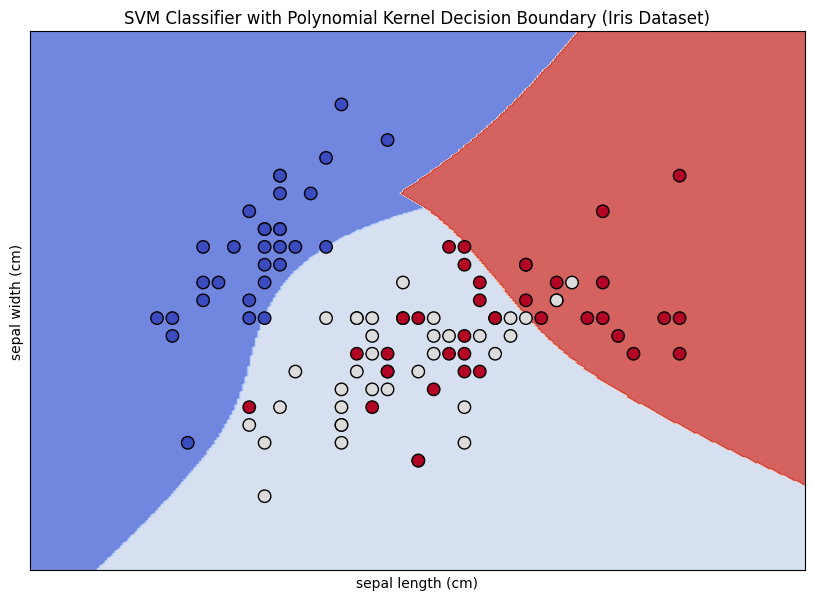

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Take only the first two features for easy visualization
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (important for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM Classifier with a Polynomial Kernel
# degree: degree of the polynomial kernel function (e.g., 3)
# C: regularization parameter
# gamma: kernel coefficient (often 'scale' or 'auto' for RBF/Poly kernels)
svm_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale', random_state=42)

# Train the classifier on the scaled training data
svm_poly.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_poly = svm_poly.predict(X_test_scaled)

# Calculate accuracy
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy of SVM (Polynomial Kernel) on Iris dataset: {accuracy_poly:.2f}")

# --- Visualize the decision boundary ---

# Create a mesh to plot in
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and training points
fig = plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=80)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('SVM Classifier with Polynomial Kernel Decision Boundary (Iris Dataset)')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.grid(True)
plt.show()

### 25:- Train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy

In [48]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

# Split the dataset into training and testing sets
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.3, random_state=42)

# Initialize the Gaussian Naïve Bayes classifier
gnb_classifier = GaussianNB()

# Train the classifier on the training data
gnb_classifier.fit(X_train_bc, y_train_bc)

# Make predictions on the test data
y_pred_bc = gnb_classifier.predict(X_test_bc)

# Calculate the accuracy
accuracy_bc = accuracy_score(y_test_bc, y_pred_bc)

# Display the accuracy
print(f"Accuracy of Gaussian Naïve Bayes on Breast Cancer dataset: {accuracy_bc:.2f}")

Accuracy of Gaussian Naïve Bayes on Breast Cancer dataset: 0.94


### 26:- Train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset

In [49]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the 20 Newsgroups dataset
# We'll select a few categories for simplicity, or load all by default
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

print(f"Number of training documents: {len(newsgroups_train.data)}")
print(f"Number of testing documents: {len(newsgroups_test.data)}")
print(f"Categories: {newsgroups_train.target_names}")

# 2. Preprocess the text data using TF-IDF Vectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) transforms text into numerical feature vectors
vectorizer = TfidfVectorizer()
X_train_text = vectorizer.fit_transform(newsgroups_train.data)
X_test_text = vectorizer.transform(newsgroups_test.data)

y_train_text = newsgroups_train.target
y_test_text = newsgroups_test.target

print(f"Shape of training data after vectorization: {X_train_text.shape}")
print(f"Shape of testing data after vectorization: {X_test_text.shape}")

# 3. Initialize and Train the Multinomial Naïve Bayes classifier
mnb_classifier = MultinomialNB()
mnb_classifier.fit(X_train_text, y_train_text)

# 4. Make predictions on the test data
y_pred_text = mnb_classifier.predict(X_test_text)

# 5. Evaluate the classifier's performance
accuracy_text = accuracy_score(y_test_text, y_pred_text)
print(f"\nAccuracy of Multinomial Naïve Bayes on 20 Newsgroups dataset: {accuracy_text:.2f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_text, target_names=newsgroups_test.target_names))

Number of training documents: 2257
Number of testing documents: 1502
Categories: ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
Shape of training data after vectorization: (2257, 35788)
Shape of testing data after vectorization: (1502, 35788)

Accuracy of Multinomial Naïve Bayes on 20 Newsgroups dataset: 0.83

Classification Report:
                        precision    recall  f1-score   support

           alt.atheism       0.97      0.60      0.74       319
         comp.graphics       0.96      0.89      0.92       389
               sci.med       0.97      0.81      0.88       396
soc.religion.christian       0.65      0.99      0.78       398

              accuracy                           0.83      1502
             macro avg       0.89      0.82      0.83      1502
          weighted avg       0.88      0.83      0.84      1502



### 27:- Train an SVM Classifier with different C values and compare the decision boundaries visually

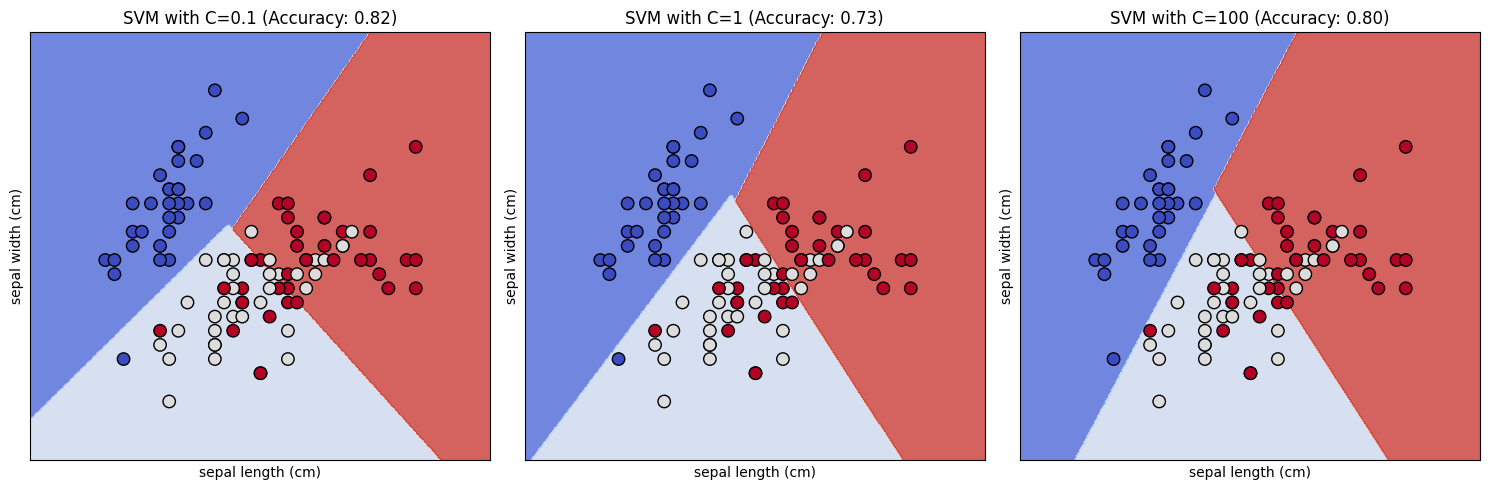

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Take only the first two features for easy visualization
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (important for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define different C values to compare
C_values = [0.1, 1, 100]

# Create a mesh to plot in
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

plt.figure(figsize=(15, 5))

for i, C_val in enumerate(C_values):
    # Initialize and train SVM with current C value (using linear kernel for clarity)
    svm_classifier = SVC(kernel='linear', C=C_val, random_state=42)
    svm_classifier.fit(X_train_scaled, y_train)

    # Make predictions on the test data (for accuracy)
    y_pred = svm_classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    # Predict class for each point in the mesh
    Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and training points
    plt.subplot(1, len(C_values), i + 1)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=80)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(f'SVM with C={C_val} (Accuracy: {accuracy:.2f})')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.grid(True)

plt.tight_layout()
plt.show()

### 28:- Train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features

In [51]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Generate a synthetic binary dataset
# Using make_classification to create a dataset, then binarize the features.
X_synthetic, y_synthetic = make_classification(
    n_samples=1000,         # 1000 samples
    n_features=20,          # 20 features
    n_informative=10,       # 10 informative features
    n_redundant=5,          # 5 redundant features
    n_repeated=0,           # 0 repeated features
    n_classes=2,            # Binary classification
    n_clusters_per_class=2, # Two clusters per class
    random_state=42
)

# Binarize the features (important for Bernoulli Naïve Bayes)
# We'll set a threshold, e.g., features > median become 1, otherwise 0.
# For simplicity, we'll just round to 0 or 1 for this example,
# but a more robust binarization might involve a specific threshold.
X_binary = (X_synthetic > np.median(X_synthetic, axis=0)).astype(int)

print(f"Shape of binary features: {X_binary.shape}")
print("First 5 rows of binary features:\n", X_binary[:5])

# 2. Split the dataset into training and testing sets
X_train_bnb, X_test_bnb, y_train_bnb, y_test_bnb = train_test_split(X_binary, y_synthetic, test_size=0.3, random_state=42)

# 3. Initialize the Bernoulli Naïve Bayes classifier
# binarize=None is used because features are already binary.
# alpha is for Laplace smoothing to handle zero probabilities.
bnb_classifier = BernoulliNB(alpha=1.0, binarize=None)

# 4. Train the classifier on the training data
bnb_classifier.fit(X_train_bnb, y_train_bnb)

# 5. Make predictions on the test data
y_pred_bnb = bnb_classifier.predict(X_test_bnb)

# 6. Evaluate the classifier's performance
accuracy_bnb = accuracy_score(y_test_bnb, y_pred_bnb)
print(f"\nAccuracy of Bernoulli Naïve Bayes on synthetic binary dataset: {accuracy_bnb:.2f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_bnb, y_pred_bnb))

Shape of binary features: (1000, 20)
First 5 rows of binary features:
 [[1 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0]
 [1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1]
 [0 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 1 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0]
 [1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1]]

Accuracy of Bernoulli Naïve Bayes on synthetic binary dataset: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       160
           1       0.70      0.71      0.70       140

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300



### 29:- Apply feature scaling before training an SVM model and compare results with unscaled data

In [52]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset (a common choice for demonstrating scaling impacts)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# --- 1. Train SVM on UNCALED data ---
print("\n--- Training SVM on UNCALED data ---")
svm_unscaled = SVC(kernel='rbf', random_state=42) # RBF kernel is sensitive to scaling
svm_unscaled.fit(X_train, y_train)
y_pred_unscaled = svm_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"Accuracy of SVM (unscaled data): {accuracy_unscaled:.2f}")

# --- 2. Apply Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. Train SVM on SCALED data ---
print("\n--- Training SVM on SCALED data ---")
svm_scaled = SVC(kernel='rbf', random_state=42)
svm_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = svm_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy of SVM (scaled data): {accuracy_scaled:.2f}")

# --- 4. Compare Results ---
print("\n--- Comparison of Accuracies ---")
print(f"Accuracy with Unscaled Data: {accuracy_unscaled:.2f}")
print(f"Accuracy with Scaled Data:   {accuracy_scaled:.2f}")

if accuracy_scaled > accuracy_unscaled:
    print("Feature scaling significantly improved SVM performance.")
elif accuracy_unscaled > accuracy_scaled:
    print("Unscaled data performed slightly better, which is unusual for RBF kernel SVM but can happen depending on the dataset characteristics.")
else:
    print("Both scaled and unscaled data resulted in similar SVM performance.")


--- Training SVM on UNCALED data ---
Accuracy of SVM (unscaled data): 1.00

--- Training SVM on SCALED data ---
Accuracy of SVM (scaled data): 1.00

--- Comparison of Accuracies ---
Accuracy with Unscaled Data: 1.00
Accuracy with Scaled Data:   1.00
Both scaled and unscaled data resulted in similar SVM performance.


### 30:- Compare Gaussian Naïve Bayes with and without `var_smoothing` (analogous to Laplace Smoothing)

### 31:- Train an SVM Classifier and use `GridSearchCV` to tune the hyperparameters (`C`, `gamma`, `kernel`)

In [54]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# It's crucial to scale data for SVMs, especially with RBF and Polynomial kernels.
# Apply StandardScaler to the data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid for GridSearchCV
# We'll explore different kernels, C values, and gamma values.
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'], # Kernel coefficient for 'rbf', 'poly', 'sigmoid'
    'kernel': ['linear', 'rbf', 'poly'] # Different kernel types
}

# Initialize the SVC model
svc_model = SVC(random_state=42)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# verbose=1 will show some progress
# n_jobs=-1 will use all available CPU cores
grid_search = GridSearchCV(svc_model, param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the scaled training data
print("\nPerforming Grid Search for optimal hyperparameters...")
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters found
print("\nBest parameters found:", grid_search.best_params_)

# Print the best cross-validation score
print("Best cross-validation accuracy:", f"{grid_search.best_score_:.2f}")

# Get the best estimator (model) from GridSearchCV
best_svc_model = grid_search.best_estimator_

# Make predictions on the scaled test data using the best model
y_pred_tuned = best_svc_model.predict(X_test_scaled)

# Evaluate the best model's performance on the test set
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nTest accuracy with best parameters: {accuracy_tuned:.2f}")
print("Classification Report for best model:\n", classification_report(y_test, y_pred_tuned))


Performing Grid Search for optimal hyperparameters...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters found: {'C': 0.1, 'gamma': 1, 'kernel': 'poly'}
Best cross-validation accuracy: 0.96

Test accuracy with best parameters: 0.98
Classification Report for best model:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [53]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load the Breast Cancer dataset
bc = load_breast_cancer()
X = bc.data
y = bc.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Gaussian Naïve Bayes WITHOUT var_smoothing (default) ---
print("\n--- Gaussian Naïve Bayes WITHOUT var_smoothing ---")
gnb_no_smoothing = GaussianNB()
gnb_no_smoothing.fit(X_train, y_train)
y_pred_no_smoothing = gnb_no_smoothing.predict(X_test)
accuracy_no_smoothing = accuracy_score(y_test, y_pred_no_smoothing)
print(f"Accuracy (no smoothing): {accuracy_no_smoothing:.2f}")
print("Classification Report (no smoothing):\n", classification_report(y_test, y_pred_no_smoothing))

# --- Gaussian Naïve Bayes WITH var_smoothing ---
# A common value for var_smoothing is 1e-9 (default in some versions),
# but we can try a slightly larger one to see potential effect, e.g., 1e-6
print("\n--- Gaussian Naïve Bayes WITH var_smoothing (1e-6) ---")
gnb_with_smoothing = GaussianNB(var_smoothing=1e-6)
gnb_with_smoothing.fit(X_train, y_train)
y_pred_with_smoothing = gnb_with_smoothing.predict(X_test)
accuracy_with_smoothing = accuracy_score(y_test, y_pred_with_smoothing)
print(f"Accuracy (with smoothing): {accuracy_with_smoothing:.2f}")
print("Classification Report (with smoothing):\n", classification_report(y_test, y_pred_with_smoothing))

# --- Compare Accuracies ---
print("\n--- Comparison of Accuracies ---")
print(f"Accuracy without var_smoothing: {accuracy_no_smoothing:.2f}")
print(f"Accuracy with var_smoothing:    {accuracy_with_smoothing:.2f}")

if accuracy_with_smoothing > accuracy_no_smoothing:
    print("Applying var_smoothing improved performance.")
elif accuracy_no_smoothing > accuracy_with_smoothing:
    print("Without var_smoothing performed slightly better or similarly. The effect can be dataset-dependent.")
else:
    print("Both models achieved similar performance, indicating var_smoothing had little impact on this dataset for the chosen value.")


--- Gaussian Naïve Bayes WITHOUT var_smoothing ---
Accuracy (no smoothing): 0.94
Classification Report (no smoothing):
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


--- Gaussian Naïve Bayes WITH var_smoothing (1e-6) ---
Accuracy (with smoothing): 0.95
Classification Report (with smoothing):
               precision    recall  f1-score   support

           0       0.98      0.89      0.93        63
           1       0.94      0.99      0.96       108

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171


--- Comparison of Accuracies ---
Accuracy without var_smoothing: 0.94
Accuracy with var_smoothi

### 32:- Train an SVM Classifier on an imbalanced dataset and apply class weighting to check if it improves accuracy

In [55]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic imbalanced dataset
# n_samples: total number of samples
# n_features: total number of features
# n_informative: number of informative features
# n_redundant: number of redundant features
# n_classes: number of classes (binary for simplicity)
# weights: proportions of samples assigned to each class (e.g., [0.9, 0.1] for imbalance)
# flip_y: percentage of samples whose class is randomly flipped (noise)
# random_state: for reproducibility
X_imbalanced, y_imbalanced = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    weights=[0.9, 0.1], # 90% majority class, 10% minority class
    flip_y=0.01,
    random_state=42
)

print(f"Original dataset shape (X): {X_imbalanced.shape}")
print(f"Original dataset shape (y): {y_imbalanced.shape}")
print(f"Class distribution: {{0: {np.sum(y_imbalanced == 0)}, 1: {np.sum(y_imbalanced == 1)}}}\n")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imbalanced, y_imbalanced, test_size=0.3, random_state=42, stratify=y_imbalanced) # Stratify to maintain class distribution

print(f"Training set class distribution: {{0: {np.sum(y_train == 0)}, 1: {np.sum(y_train == 1)}}})")
print(f"Testing set class distribution: {{0: {np.sum(y_test == 0)}, 1: {np.sum(y_test == 1)}}}\n")

# Scale features (important for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. Train SVM without class weighting (Baseline) ---
print("--- SVM Classifier WITHOUT Class Weighting ---")
svm_no_weights = SVC(kernel='rbf', random_state=42)
svm_no_weights.fit(X_train_scaled, y_train)
y_pred_no_weights = svm_no_weights.predict(X_test_scaled)

accuracy_no_weights = accuracy_score(y_test, y_pred_no_weights)
print(f"Accuracy (no weights): {accuracy_no_weights:.2f}")
print("Classification Report (no weights):\n", classification_report(y_test, y_pred_no_weights))

# --- 4. Train SVM WITH Class Weighting ---
print("\n--- SVM Classifier WITH Class Weighting (balanced) ---")
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
svm_with_weights = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_with_weights.fit(X_train_scaled, y_train)
y_pred_with_weights = svm_with_weights.predict(X_test_scaled)

accuracy_with_weights = accuracy_score(y_test, y_pred_with_weights)
print(f"Accuracy (with weights): {accuracy_with_weights:.2f}")
print("Classification Report (with weights):\n", classification_report(y_test, y_pred_with_weights))

# --- 5. Compare Results ---
print("\n--- Comparison Summary ---")
print(f"Accuracy without class weights: {accuracy_no_weights:.2f}")
print(f"Accuracy with class weights:    {accuracy_with_weights:.2f}")

# It's more insightful to compare metrics for the minority class (class 1)
report_no_weights = classification_report(y_test, y_pred_no_weights, output_dict=True)
report_with_weights = classification_report(y_test, y_pred_with_weights, output_dict=True)

precision_minority_no_weights = report_no_weights['1']['precision']
recall_minority_no_weights = report_no_weights['1']['recall']
f1_minority_no_weights = report_no_weights['1']['f1-score']

precision_minority_with_weights = report_with_weights['1']['precision']
recall_minority_with_weights = report_with_weights['1']['recall']
f1_minority_with_weights = report_with_weights['1']['f1-score']

print(f"\nMinority Class (1) - Precision (no weights): {precision_minority_no_weights:.2f}, (with weights): {precision_minority_with_weights:.2f}")
print(f"Minority Class (1) - Recall (no weights):    {recall_minority_no_weights:.2f}, (with weights): {recall_minority_with_weights:.2f}")
print(f"Minority Class (1) - F1-Score (no weights):  {f1_minority_no_weights:.2f}, (with weights): {f1_minority_with_weights:.2f}")

if f1_minority_with_weights > f1_minority_no_weights:
    print("\nApplying class weights improved the F1-score for the minority class.")
elif f1_minority_no_weights > f1_minority_with_weights:
    print("\nWithout class weights performed better or similarly for the minority class.")
else:
    print("\nBoth models achieved similar F1-score for the minority class.")

Original dataset shape (X): (1000, 20)
Original dataset shape (y): (1000,)
Class distribution: {0: 892, 1: 108}

Training set class distribution: {0: 624, 1: 76})
Testing set class distribution: {0: 268, 1: 32}

--- SVM Classifier WITHOUT Class Weighting ---
Accuracy (no weights): 0.95
Classification Report (no weights):
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       268
           1       1.00      0.50      0.67        32

    accuracy                           0.95       300
   macro avg       0.97      0.75      0.82       300
weighted avg       0.95      0.95      0.94       300


--- SVM Classifier WITH Class Weighting (balanced) ---
Accuracy (with weights): 0.95
Classification Report (with weights):
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       268
           1       0.72      0.81      0.76        32

    accuracy                           0.95       300
   mac

### 33:- Train a Naïve Bayes classifier for spam detection using email data

### 34:- Perform Feature Selection with Naïve Bayes Classifier

In [61]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, chi2

# Load the Breast Cancer dataset
bc = load_breast_cancer()
X = bc.data
y = bc.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 1. Train Gaussian Naïve Bayes WITHOUT Feature Selection (Baseline) ---
print("--- Gaussian Naïve Bayes WITHOUT Feature Selection ---")
gnb_no_fs = GaussianNB()
gnb_no_fs.fit(X_train, y_train)
y_pred_no_fs = gnb_no_fs.predict(X_test)
accuracy_no_fs = accuracy_score(y_test, y_pred_no_fs)
print(f"Accuracy (no feature selection): {accuracy_no_fs:.2f}")
print("Classification Report (no feature selection):\n", classification_report(y_test, y_pred_no_fs))

# --- 2. Perform Feature Selection ---
# Select the top K features based on chi-squared statistics
# The chi2 (chi-squared) test works well for non-negative features like those in Breast Cancer dataset.
k_features = 15 # Let's select 15 best features as an example
selector = SelectKBest(chi2, k=k_features)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"\nOriginal number of features: {X_train.shape[1]}")
print(f"Number of features after selection: {X_train_selected.shape[1]}")

# Get the names of the selected features (optional, for understanding)
selected_features_indices = selector.get_support(indices=True)
selected_feature_names = [bc.feature_names[i] for i in selected_features_indices]
print("Selected features:", selected_feature_names)

# --- 3. Train Gaussian Naïve Bayes WITH Feature Selection ---
print("\n--- Gaussian Naïve Bayes WITH Feature Selection ---")
gnb_with_fs = GaussianNB()
gnb_with_fs.fit(X_train_selected, y_train)
y_pred_with_fs = gnb_with_fs.predict(X_test_selected)
accuracy_with_fs = accuracy_score(y_test, y_pred_with_fs)
print(f"Accuracy (with feature selection): {accuracy_with_fs:.2f}")
print("Classification Report (with feature selection):\n", classification_report(y_test, y_pred_with_fs))

# --- 4. Compare Results ---
print("\n--- Comparison of Accuracies ---")
print(f"Accuracy without feature selection: {accuracy_no_fs:.2f}")
print(f"Accuracy with feature selection:    {accuracy_with_fs:.2f}")

if accuracy_with_fs > accuracy_no_fs:
    print("\nFeature selection improved the Naïve Bayes classifier's performance.")
elif accuracy_no_fs > accuracy_with_fs:
    print("\nWithout feature selection performed slightly better or similarly. The effect can be dataset and feature selection method dependent.")
else:
    print("\nBoth models achieved similar performance.")

--- Gaussian Naïve Bayes WITHOUT Feature Selection ---
Accuracy (no feature selection): 0.94
Classification Report (no feature selection):
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


Original number of features: 30
Number of features after selection: 15
Selected features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean concavity'), np.str_('radius error'), np.str_('perimeter error'), np.str_('area error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points')]

--- Gaussian Naïve Bayes WITH Feature Selectio

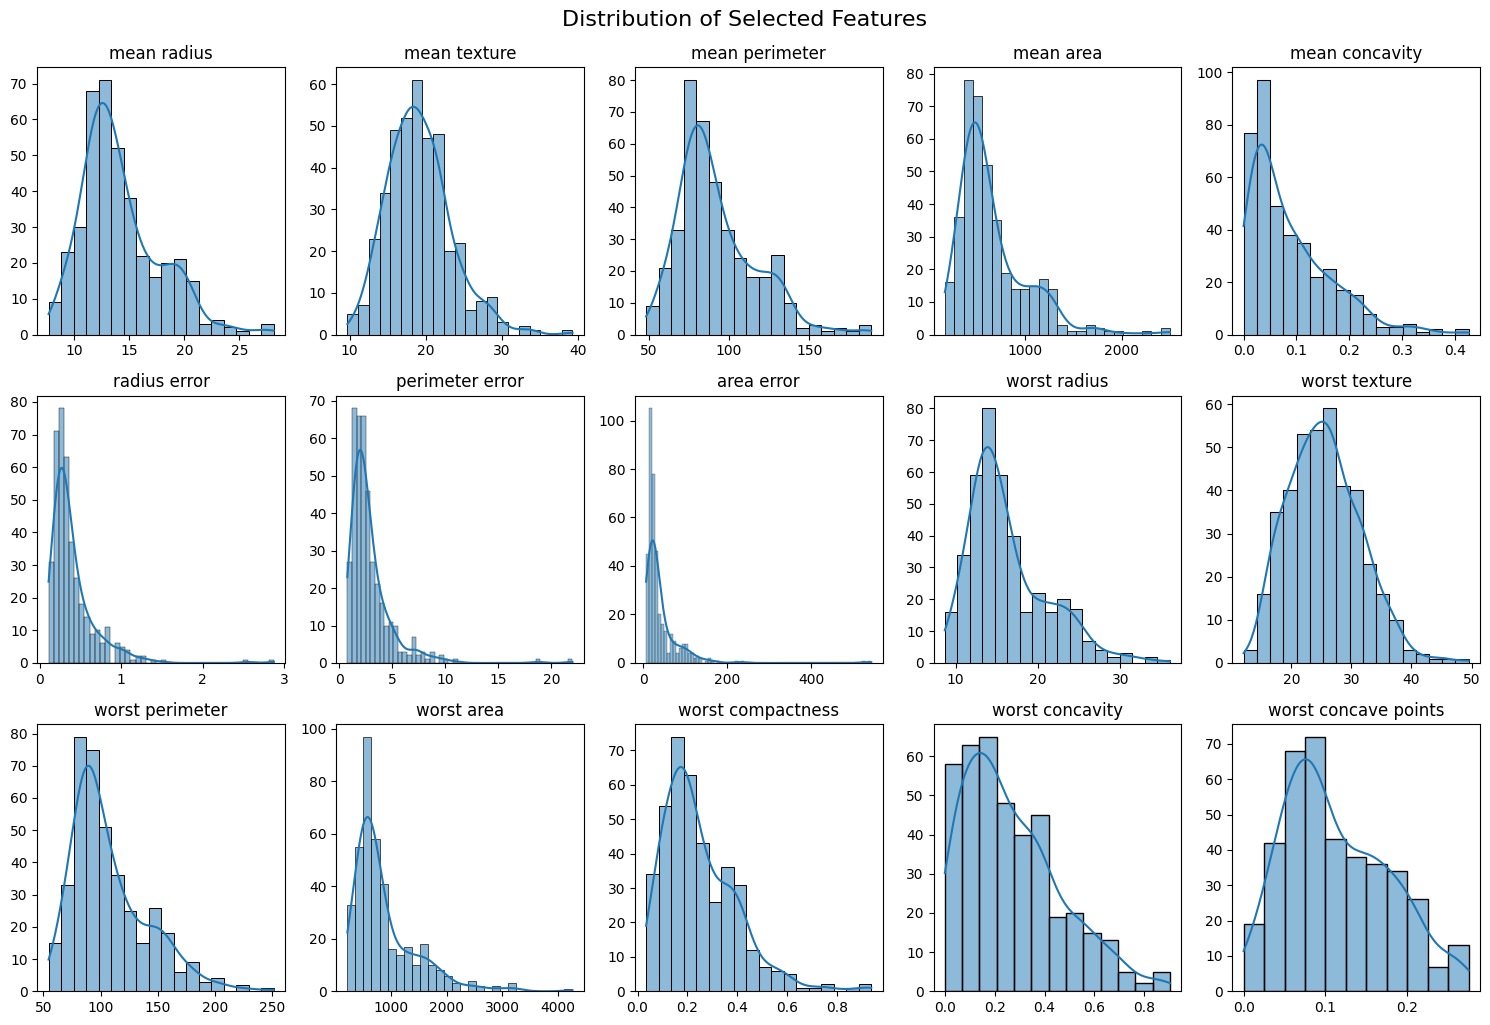

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
df_selected_features = pd.DataFrame(X_train_selected, columns=selected_feature_names)

# Plot the distribution of each selected feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_feature_names):
    plt.subplot(3, 5, i + 1) # Adjust subplot grid as needed based on k_features
    sns.histplot(df_selected_features[feature], kde=True)
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Distribution of Selected Features', y=1.02, fontsize=16)
plt.show()

In [57]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Create a synthetic dataset for demonstration
# In a real-world scenario, you would load an actual email dataset (e.g., from Kaggle).
# Here, we create a small list of emails and their labels (spam=1, not spam=0).
emails = [
    "Congratulations! You've won a free iPhone! Click here.", # Spam
    "Meeting reminder for tomorrow at 10 AM.", # Not Spam
    "Earn money fast! Exclusive offer just for you.", # Spam
    "Hello, please review the attached document for the project.", # Not Spam
    "Claim your prize now! Limited time offer.", # Spam
    "Your account has been compromised. Verify your details.", # Spam
    "Hey, how are you doing? Let's catch up soon.", # Not Spam
    "Viagra pills at discount price. Buy now!", # Spam
    "Regarding the Q3 report, it's due next week.", # Not Spam
    "Free gift card for our loyal customers. Don't miss out!", # Spam
    "Can you send me the latest sales figures?", # Not Spam
    "URGENT: Your parcel delivery is delayed. Confirm details.", # Spam
    "Dinner plans for Saturday? Let me know.", # Not Spam
    "Investment opportunity: Make millions from home.", # Spam
    "Project update: The new features are live.", # Not Spam
    "You have a new message from a secret admirer.", # Spam
    "Reminder: Your subscription is expiring soon.", # Not Spam
    "Unlock exclusive content with our premium membership!", # Spam
    "Here is the agenda for our next board meeting.", # Not Spam
    "Winning lottery numbers for today! Check if you're rich.", # Spam
    "Please confirm your attendance for the webinar.", # Not Spam
    "Huge discounts on branded watches. Shop now!", # Spam
    "Your order has been shipped. Tracking details inside." # Not Spam
]
labels = [
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0, # Not Spam
    1, # Spam
    0  # Not Spam
]

df_emails = pd.DataFrame({'email': emails, 'label': labels})

print("Sample Data:")
display(df_emails.head())
print(f"\nClass distribution: {df_emails['label'].value_counts()}")

# 2. Preprocess the text data using TF-IDF Vectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) transforms text into numerical feature vectors
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X = vectorizer.fit_transform(df_emails['email'])
y = df_emails['label']

print(f"\nShape of data after TF-IDF vectorization: {X.shape}")

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set samples: {X_train.shape[0]}, Testing set samples: {X_test.shape[0]}")
print(f"Training set class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Testing set class distribution:\n{pd.Series(y_test).value_counts()}")

# 4. Initialize and Train the Multinomial Naïve Bayes classifier
# MultinomialNB is well-suited for text classification with word counts or TF-IDF features.
# Increased alpha to 1.0 (Laplace smoothing) to help with sparse data and unseen features in test set
mnb_classifier_spam = MultinomialNB(alpha=1.0)
mnb_classifier_spam.fit(X_train, y_train)

# 5. Make predictions on the test data
y_pred_spam = mnb_classifier_spam.predict(X_test)

# 6. Evaluate the classifier's performance
accuracy_spam = accuracy_score(y_test, y_pred_spam)
print(f"\nAccuracy of Multinomial Naïve Bayes for Spam Detection: {accuracy_spam:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_spam))

Sample Data:


,email,label
0,Congratulations! You've won a free iPhone! Cli...,1
1,Meeting reminder for tomorrow at 10 AM.,0
2,Earn money fast! Exclusive offer just for you.,1
3,"Hello, please review the attached document for...",0
4,Claim your prize now! Limited time offer.,1



Class distribution: label
1    12
0    11
Name: count, dtype: int64

Shape of data after TF-IDF vectorization: (23, 99)

Training set samples: 16, Testing set samples: 7
Training set class distribution:
label
0    8
1    8
Name: count, dtype: int64
Testing set class distribution:
label
1    4
0    3
Name: count, dtype: int64

Accuracy of Multinomial Naïve Bayes for Spam Detection: 0.43

Classification Report:
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       0.00      0.00      0.00         4

    accuracy                           0.43         7
   macro avg       0.21      0.50      0.30         7
weighted avg       0.18      0.43      0.26         7



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
from sklearn.linear_model import LogisticRegression

print("\n--- Training Logistic Regression Classifier for Spam Detection ---")
# Initialize and Train the Logistic Regression classifier
# Increased max_iter for convergence on small datasets if needed
logistic_reg_classifier_spam = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
logistic_reg_classifier_spam.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr_spam = logistic_reg_classifier_spam.predict(X_test)

# Evaluate the classifier's performance
accuracy_lr_spam = accuracy_score(y_test, y_pred_lr_spam)
print(f"Accuracy of Logistic Regression for Spam Detection: {accuracy_lr_spam:.2f}")

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr_spam))


--- Training Logistic Regression Classifier for Spam Detection ---
Accuracy of Logistic Regression for Spam Detection: 0.29

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       0.00      0.00      0.00         4

    accuracy                           0.29         7
   macro avg       0.17      0.33      0.22         7
weighted avg       0.14      0.29      0.19         7



### Comparison of Multinomial Naïve Bayes and Logistic Regression for Spam Detection

Let's summarize the performance of both models:

In [59]:
print(f"Multinomial Naïve Bayes Accuracy: {accuracy_spam:.2f}")
print(f"Logistic Regression Accuracy: {accuracy_lr_spam:.2f}")

print("\n--- Detailed Comparison ---")
print("Multinomial Naïve Bayes (alpha=1.0) Report:")
print(classification_report(y_test, y_pred_spam, zero_division=0)) # zero_division=0 to handle UndefinedMetricWarning gracefully

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr_spam, zero_division=0))

if accuracy_lr_spam > accuracy_spam:
    print("\nLogistic Regression performed better in terms of overall accuracy.")
elif accuracy_spam > accuracy_lr_spam:
    print("\nMultinomial Naïve Bayes performed better in terms of overall accuracy.")
else:
    print("\nBoth models achieved similar overall accuracy.")

# For imbalanced datasets, it's more important to look at minority class metrics.
# Class 1 is 'spam' (minority class in terms of detection difficulty here)
report_mnb = classification_report(y_test, y_pred_spam, output_dict=True, zero_division=0)
report_lr = classification_report(y_test, y_pred_lr_spam, output_dict=True, zero_division=0)

f1_mnb_spam = report_mnb['1']['f1-score']
f1_lr_spam = report_lr['1']['f1-score']

print(f"\nF1-score for Spam (Class 1) - Naïve Bayes: {f1_mnb_spam:.2f}")
print(f"F1-score for Spam (Class 1) - Logistic Regression: {f1_lr_spam:.2f}")

if f1_lr_spam > f1_mnb_spam:
    print("Logistic Regression showed a better F1-score for detecting spam.")
elif f1_mnb_spam > f1_lr_spam:
    print("Multinomial Naïve Bayes showed a better F1-score for detecting spam.")
else:
    print("Both models achieved similar F1-score for detecting spam.")

print("\nIt's important to note that with a very small and synthetic dataset, these results may not be representative of real-world performance. A larger, more diverse dataset would be needed for a robust comparison.")

Multinomial Naïve Bayes Accuracy: 0.43
Logistic Regression Accuracy: 0.29

--- Detailed Comparison ---
Multinomial Naïve Bayes (alpha=1.0) Report:
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       0.00      0.00      0.00         4

    accuracy                           0.43         7
   macro avg       0.21      0.50      0.30         7
weighted avg       0.18      0.43      0.26         7


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       0.00      0.00      0.00         4

    accuracy                           0.29         7
   macro avg       0.17      0.33      0.22         7
weighted avg       0.14      0.29      0.19         7


Multinomial Naïve Bayes performed better in terms of overall accuracy.

F1-score for Spam (Class 1) - Naïve Bayes: 0.00
F1-score for Spam (Class 1) - Logistic Regression

### 34:- Train and Compare SVM and Gaussian Naïve Bayes Classifiers on the Iris Dataset

In [60]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling (important for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. Train SVM Classifier ---
print("\n--- Training SVM Classifier ---")
svm_classifier = SVC(kernel='rbf', random_state=42) # Using RBF kernel, common for many datasets
svm_classifier.fit(X_train_scaled, y_train)
y_pred_svm = svm_classifier.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of SVM Classifier: {accuracy_svm:.2f}")

# --- 2. Train Gaussian Naïve Bayes Classifier ---
print("\n--- Training Gaussian Naïve Bayes Classifier ---")
gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train_scaled, y_train)
y_pred_gnb = gnb_classifier.predict(X_test_scaled)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Accuracy of Gaussian Naïve Bayes Classifier: {accuracy_gnb:.2f}")

# --- 3. Compare Accuracies ---
print("\n--- Comparison of Accuracies ---")
print(f"SVM Classifier Accuracy: {accuracy_svm:.2f}")
print(f"Gaussian Naïve Bayes Classifier Accuracy: {accuracy_gnb:.2f}")

if accuracy_svm > accuracy_gnb:
    print("\nSVM Classifier performed better on this dataset.")
elif accuracy_gnb > accuracy_svm:
    print("\nGaussian Naïve Bayes Classifier performed better on this dataset.")
else:
    print("\nBoth classifiers achieved similar performance on this dataset.")


--- Training SVM Classifier ---
Accuracy of SVM Classifier: 1.00

--- Training Gaussian Naïve Bayes Classifier ---
Accuracy of Gaussian Naïve Bayes Classifier: 0.98

--- Comparison of Accuracies ---
SVM Classifier Accuracy: 1.00
Gaussian Naïve Bayes Classifier Accuracy: 0.98

SVM Classifier performed better on this dataset.
